<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/class_8_skilll_morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings; warnings.filterwarnings('ignore')
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [ ]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


--- Question 1: Testing Tree Depths ---
Depth: 2 | Accuracy: 0.5366 (53.66%)
Depth: 3 | Accuracy: 0.6147 (61.47%)
Depth: 4 | Accuracy: 0.7447 (74.47%)
Depth: 5 | Accuracy: 0.7967 (79.67%)
Depth: 6 | Accuracy: 0.8913 (89.13%)
Depth: 7 | Accuracy: 0.9031 (90.31%)

🌟 Optimal Max Depth: 7 with Accuracy: 90.31%

--- Question 2: Classification Performance Report ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.95      0.94        58
      Normal_Weight       0.82      0.80      0.81        64
     Obesity_Type_I       0.92      0.95      0.94        64
    Obesity_Type_II       0.97      0.93      0.95        61
   Obesity_Type_III       1.00      1.00      1.00        61
 Overweight_Level_I       0.78      0.84      0.81        64
Overweight_Level_II       0.91      0.84      0.88        51

           accuracy                           0.90       423
          macro avg       0.91      0.90      0.90       423
       weighted avg      

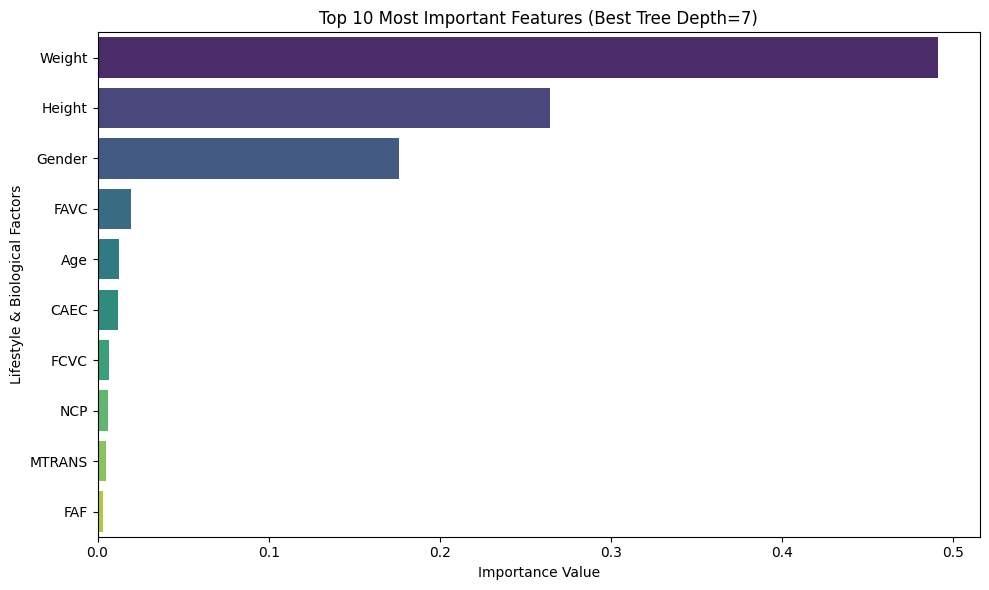

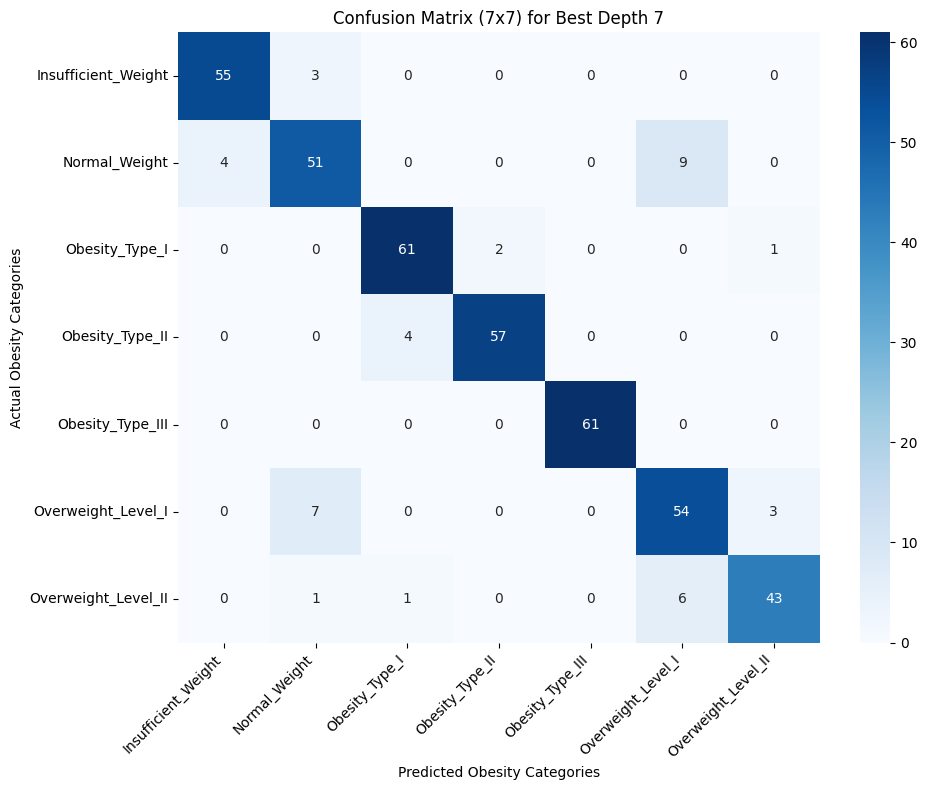

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =====================================================================
# 0. LOAD AND PREPROCESS DATA
# =====================================================================
# Load your uploaded dataset
obesity_data = pd.read_csv('/content/drive/MyDrive/Dataset/ObesityDataSet_raw_and_data_sinthetic.csv')

# Convert categorical variables (object types) into numbers using LabelEncoder
le = LabelEncoder()
categorical_cols = obesity_data.select_dtypes(include='object').columns

for col in categorical_cols:
    obesity_data[col] = le.fit_transform(obesity_data[col])

# Separate into Features (X) and Target (y)
X = obesity_data.drop(columns=['NObeyesdad'])
y = obesity_data['NObeyesdad']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)


# =====================================================================
# QUESTION 1: Find the Best Tree Depth
# =====================================================================
print("--- Question 1: Testing Tree Depths ---")
depths = [2, 3, 4, 5, 6, 7]
best_depth = None
best_accuracy = 0

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=20)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Depth: {depth} | Accuracy: {acc:.4f} ({acc*100:.2f}%)")

    if acc > best_accuracy:
        best_accuracy = acc
        best_depth = depth

print(f"\n🌟 Optimal Max Depth: {best_depth} with Accuracy: {best_accuracy*100:.2f}%\n")


# =====================================================================
# QUESTION 2: Calculate All Metrics using Best Depth
# =====================================================================
print("--- Question 2: Classification Performance Report ---")
best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=20)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

# Get the original text labels back for the report representation
target_labels = list(le.classes_)

print(classification_report(y_test, y_pred_best, target_names=target_labels))


# =====================================================================
# QUESTION 3: Feature Importance
# =====================================================================
# Extract feature importance values
importances = best_model.feature_importances_
feature_names = X.columns

# Combine into a DataFrame and sort
df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title(f'Top 10 Most Important Features (Best Tree Depth={best_depth})')
plt.xlabel('Importance Value')
plt.ylabel('Lifestyle & Biological Factors')
plt.tight_layout()
plt.show()


# =====================================================================
# QUESTION 4: Confusion Matrix Analysis
# =====================================================================
cm = confusion_matrix(y_test, y_pred_best)

# Plotting the 7x7 confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_labels,
            yticklabels=target_labels)
plt.title(f'Confusion Matrix (7x7) for Best Depth {best_depth}')
plt.xlabel('Predicted Obesity Categories')
plt.ylabel('Actual Obesity Categories')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()